In [1]:
import kagglehub

path = kagglehub.dataset_download("shubham2703/five-crop-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shubham2703/five-crop-diseases-dataset


In [2]:
import os
import shutil
import random

# 🔹 CORRECT path in Google Colab
input_dir = "/kaggle/input/datasets/shubham2703/five-crop-diseases-dataset/Crop Diseases Dataset/Crop Diseases/Crop___Disease"

# 🔹 Output directory (will be created in Colab working dir)
output_dir = "/content/crop_disease_dataset"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

assert train_ratio + val_ratio + test_ratio == 1.0

# Create base folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

# Loop through crops
for crop in os.listdir(input_dir):
    crop_path = os.path.join(input_dir, crop)

    if not os.path.isdir(crop_path):
        continue

    # Loop through diseases
    for disease in os.listdir(crop_path):
        disease_path = os.path.join(crop_path, disease)

        if not os.path.isdir(disease_path):
            continue

        images = [img for img in os.listdir(disease_path)
                  if os.path.isfile(os.path.join(disease_path, img))]

        random.shuffle(images)

        total = len(images)
        train_end = int(total * train_ratio)
        val_end = train_end + int(total * val_ratio)

        split_data = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        for split, files in split_data.items():
            dest_folder = os.path.join(output_dir, split, crop, disease)
            os.makedirs(dest_folder, exist_ok=True)

            for file in files:
                src = os.path.join(disease_path, file)
                dst = os.path.join(dest_folder, file)

                shutil.copy2(src, dst)

print("✅ Dataset split completed!")

✅ Dataset split completed!


In [3]:
import os
import shutil

base_dir = "/content/crop_disease_dataset"

for split in ["train", "val", "test"]:
    split_path = os.path.join(base_dir, split)

    for crop in os.listdir(split_path):
        crop_path = os.path.join(split_path, crop)

        if not os.path.isdir(crop_path):
            continue

        for disease in os.listdir(crop_path):
            disease_path = os.path.join(crop_path, disease)

            if not os.path.isdir(disease_path):
                continue

            # New combined class name
            new_class_name = f"{crop}___{disease}"
            new_class_path = os.path.join(split_path, new_class_name)

            os.makedirs(new_class_path, exist_ok=True)

            # Move images
            for img in os.listdir(disease_path):
                src = os.path.join(disease_path, img)
                dst = os.path.join(new_class_path, img)

                shutil.move(src, dst)

        # Remove empty crop folder
        shutil.rmtree(crop_path)

print("✅ Dataset flattened successfully!")

✅ Dataset flattened successfully!


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile

# 🔹 Allow loading truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

image_size = (256, 256) 
batch_size = 32

# Data augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation and test data (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    '/content/crop_disease_dataset/train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True # Shuffle training data
)

validation_generator = val_test_datagen.flow_from_directory(
    '/content/crop_disease_dataset/val',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Do NOT shuffle validation data for consistent evaluation
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/crop_disease_dataset/test',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Do NOT shuffle test data for consistent evaluation
)

print("\nData generators created successfully!")
print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Number of test samples: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

2026-04-16 15:57:32.143022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776355052.388250      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776355052.457421      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776355052.989584      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776355052.989641      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776355052.989644      55 computation_placer.cc:177] computation placer alr

Found 9322 images belonging to 17 classes.
Found 1992 images belonging to 17 classes.
Found 2010 images belonging to 17 classes.

Data generators created successfully!
Number of training samples: 9322
Number of validation samples: 1992
Number of test samples: 2010
Classes: {'Corn___Corn___Common_Rust': 0, 'Corn___Corn___Gray_Leaf_Spot': 1, 'Corn___Corn___Healthy': 2, 'Corn___Corn___Northern_Leaf_Blight': 3, 'Potato___Potato___Early_Blight': 4, 'Potato___Potato___Healthy': 5, 'Potato___Potato___Late_Blight': 6, 'Rice___Rice___Brown_Spot': 7, 'Rice___Rice___Healthy': 8, 'Rice___Rice___Leaf_Blast': 9, 'Rice___Rice___Neck_Blast': 10, 'Wheat___Wheat___Brown_Rust': 11, 'Wheat___Wheat___Healthy': 12, 'Wheat___Wheat___Yellow_Rust': 13, 'sugarcane___Bacterial Blight': 14, 'sugarcane___Healthy': 15, 'sugarcane___Red Rot': 16}


In [16]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

In [17]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

# Get the number of classes from the train_generator
num_classes = len(train_generator.class_indices)

model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=[256,256,3]))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(Conv2D(512, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Dropout(0.25))

model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu'))

model.add(Dropout(0.4))

model.add(Dense(units=num_classes,activation='softmax'))



In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 254, 254, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,847,921 (18.49 MB)

 Trainable params: 4,847,921 (18.49 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
training_history = model.fit(x=train_generator,validation_data=validation_generator,epochs=50,verbose=1)

Epoch 1/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 288s 958ms/step - accuracy: 0.2020 - loss: 2.3608 - val_accuracy: 0.4874 - val_loss: 1.5526
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 276s 944ms/step - accuracy: 0.5104 - loss: 1.4164 - val_accuracy: 0.5371 - val_loss: 1.2295
Epoch 3/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 275s 941ms/step - accuracy: 0.5910 - loss: 1.1312 - val_accuracy: 0.6099 - val_loss: 1.2067
Epoch 4/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 274s 937ms/step - accuracy: 0.6368 - loss: 1.0170 - val_accuracy: 0.6496 - val_loss: 1.0149
Epoch 5/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 274s 939ms/step - accuracy: 0.6668 - loss: 0.9186 - val_accuracy: 0.7164 - val_loss: 0.7972
Epoch 6/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 275s 943ms/step - accuracy: 0.6919 - loss: 0.8463 - val_accuracy: 0.7344 - val_loss: 0.6893
Epoch 7/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 277s 946ms/step - accuracy: 0.7064 - loss: 0.8060 - val_accuracy: 0.7113 - val_loss: 0.9147
Epoch 8/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 276s 943ms/step - accuracy: 0.7404 -

In [20]:
import json

history_dict = training_history.history

with open("training_history.json", "w") as f:
    json.dump(history_dict, f)

Model saved successfully as 'cnn_model3.h5'

Final Training Accuracy: 0.9188
Final Validation Accuracy: 0.9232


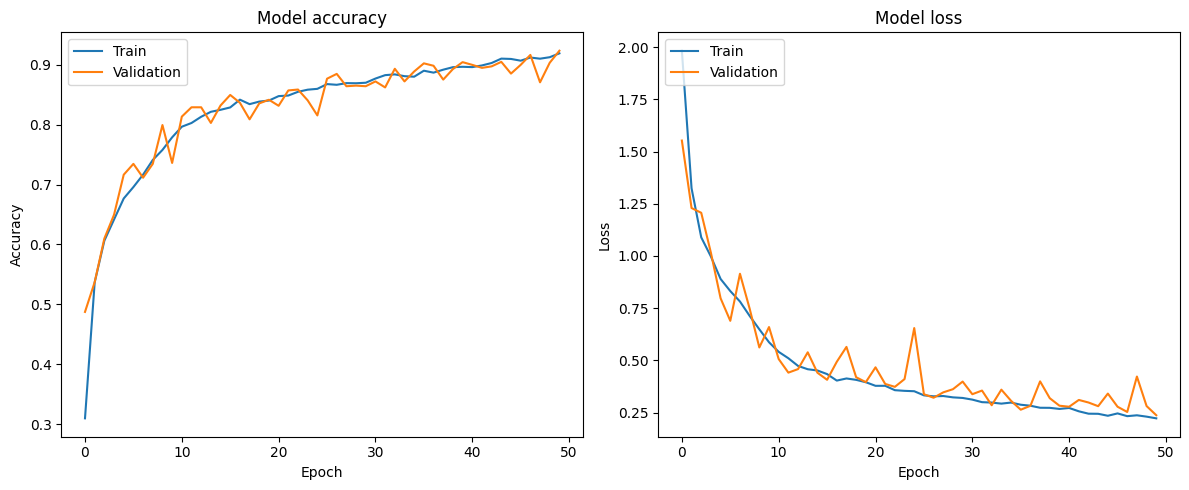

In [21]:
import matplotlib.pyplot as plt

# 1. Save the model
model.save('cnn_model_2.h5')
print("Model saved successfully as 'cnn_model3.h5'")

# 2. Print accuracy
print(f"\nFinal Training Accuracy: {training_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {training_history.history['val_accuracy'][-1]:.4f}")

# 3. Visualize accuracy
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'])
plt.plot(training_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 449ms/step

Classification Report:
                                    precision    recall  f1-score   support

         Corn___Corn___Common_Rust     1.0000    1.0000    1.0000       180
      Corn___Corn___Gray_Leaf_Spot     0.7872    0.9487    0.8605        78
             Corn___Corn___Healthy     0.9943    1.0000    0.9972       175
Corn___Corn___Northern_Leaf_Blight     0.9562    0.8792    0.9161       149
    Potato___Potato___Early_Blight     1.0000    1.0000    1.0000       150
         Potato___Potato___Healthy     1.0000    0.9583    0.9787        24
     Potato___Potato___Late_Blight     0.9933    0.9933    0.9933       150
          Rice___Rice___Brown_Spot     0.7397    0.5806    0.6506        93
             Rice___Rice___Healthy     0.7518    0.9196    0.8273       224
          Rice___Rice___Leaf_Blast     0.7542    0.6014    0.6692       148
          Rice___Rice___Neck_Blast     1.0000    0.9800    0.9899       150
        Wheat___Wheat

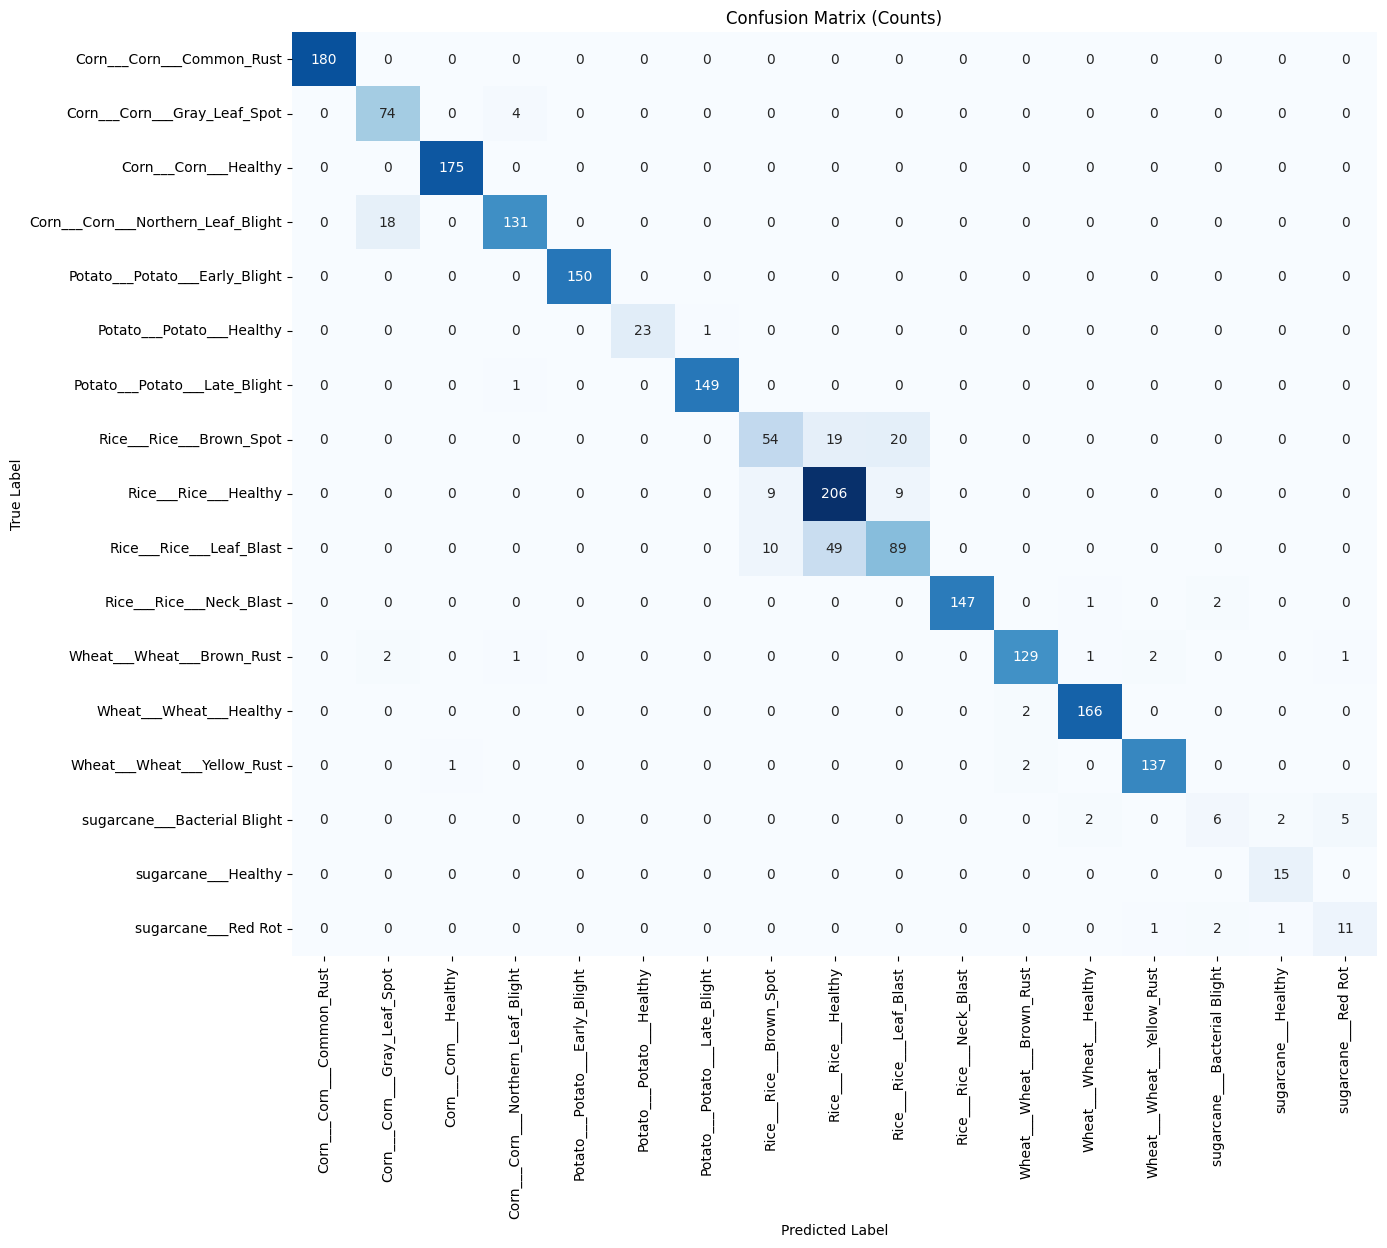

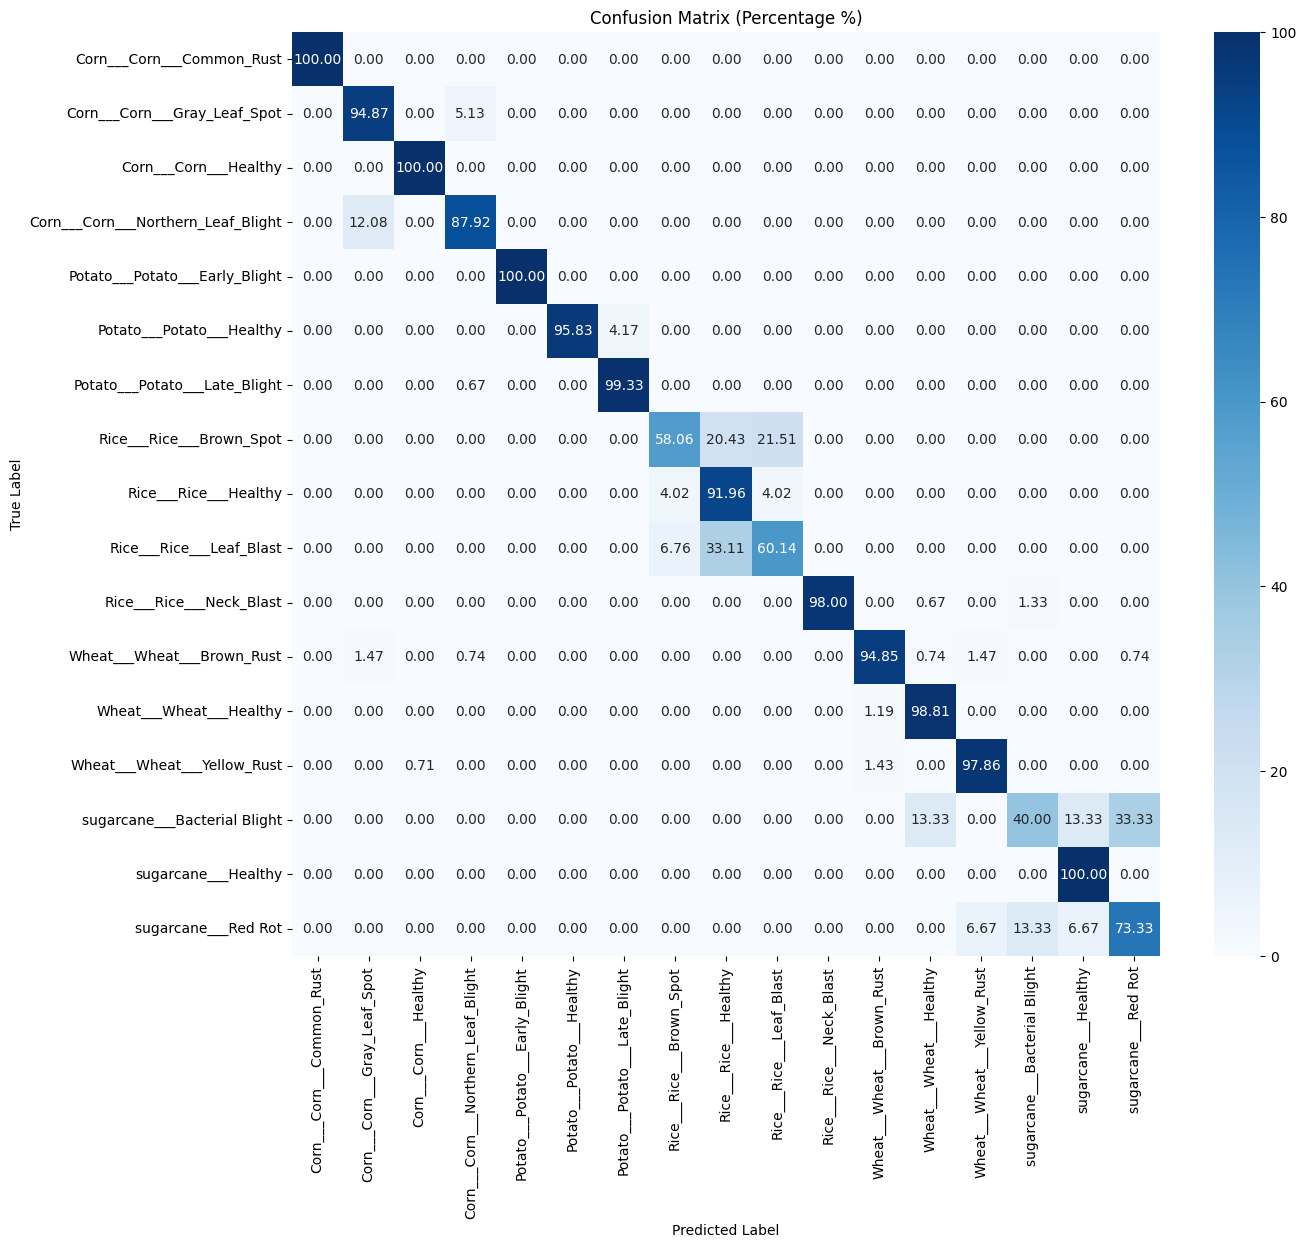

In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------
# Predict on the test data
# -----------------------------
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # convert to %

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix as Percentages
plt.figure(figsize=(14, 12))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title('Confusion Matrix (Percentage %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [23]:
model.save('cnn_model_2.h5')